In [ ]:
import sympy as sp

x = sp.Symbol('x')
f = 3*x**4
derivative = f.diff(x)

print(derivative)

12*x**3


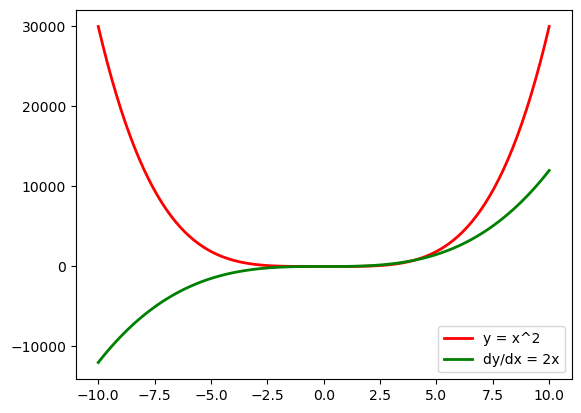

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-10, 10, 100)
y = 3*x**4
dy = 12*x**3

fig, ax = plt.subplots()
ax.plot(x, y, 'r', linewidth=2)
ax.plot(x, dy, 'g', linewidth=2)
ax.legend(['y = 3x^4', 'dy/dx = 12x^3'])
plt.show()


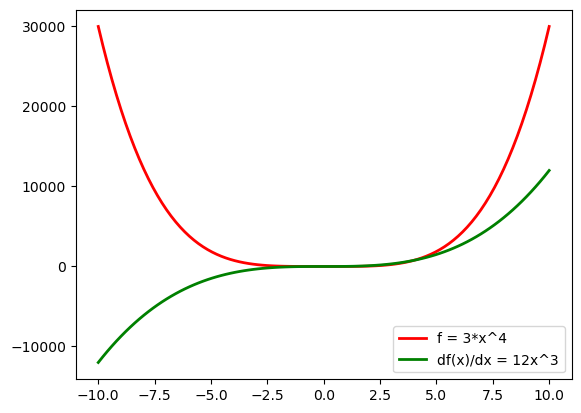

In [13]:
import matplotlib.pyplot as plt
import numpy as np

f = 3*x**4
df = 12*x**3

x = np.linspace(-10, 10, 100)
fig, ax = plt.subplots()
ax.plot(x, f, 'r', linewidth=2)
ax.plot(x, df, 'g', linewidth=2)
ax.legend(['f = 3*x^4', 'df(x)/dx = 12x^3'])

plt.show()

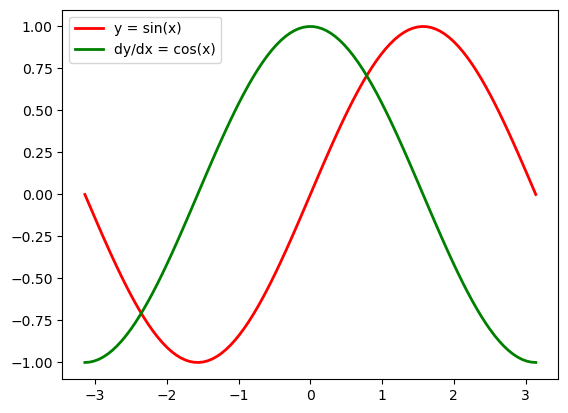

In [24]:
x = np.linspace(-np.pi, np.pi, 100)
y = np.sin(x)
dy = np.cos(x)

fig, ax = plt.subplots()
ax.plot(x, y, 'r', linewidth=2)
ax.plot(x, dy, 'g', linewidth=2)
ax.legend(['y = sin(x)', "dy/dx = cos(x)"])
plt.show()

In [23]:
x = sp.Symbol('x')
f = 3*x**4
integral = sp.integrate(f, (x, 1, 2))

print(integral)

93/5


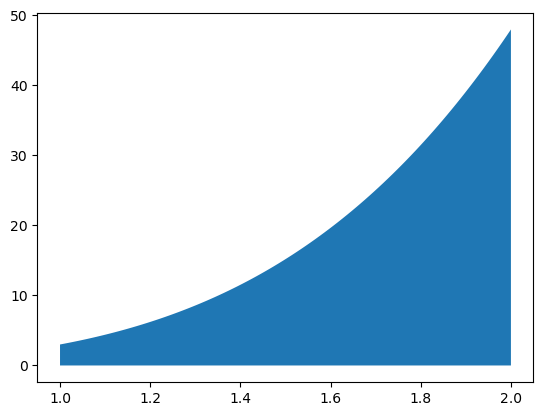

In [27]:
x = np.linspace(1, 2, 100)
y = 3*x**4

fig, ax = plt.subplots()
ax.fill_between(x, y)

plt.show()

In [28]:
x, y = sp.symbols('x y')
f = 3*x**4 + y**2

partial_x = f.diff(x)
partial_y = f.diff(y)

print(partial_x)
print(partial_y)

12*x**3
2*y


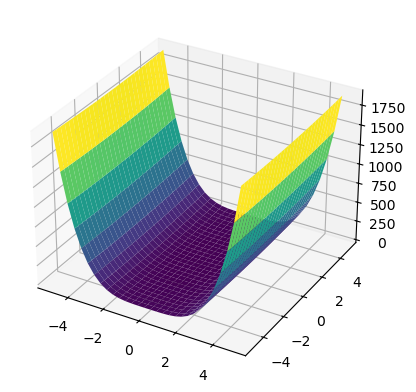

In [18]:
def f(x, y):
    return 3*x**4 + y**2

x = np.linspace(-5, 5, 30)
y = np.linspace(-5, 5, 30)

X, Y = np.meshgrid(x, y)
Z = f(X, Y)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

plt.show()


In [29]:
def f(x):
    return 3*x**4

def grad(x):
    return 12*x**3

x = 1
learning_rate = 0.1
iterations = 100

for i in range(iterations):
    x = x - learning_rate*grad(x)

print(x)
print(f(x))


-0.06120682543556698
4.210373991389923e-05


In [20]:
from scipy.integrate import solve_ivp

def dy_dx(x, y):
    return x

solution = solve_ivp(dy_dx, [0, 1], [0], t_eval=[0, 1])
y = solution.y[0]

print(y)

[0.  0.5]


# Integral

In [31]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X, y = load_breast_cancer(return_X_y=True)
clf = LogisticRegression(solver="newton-cholesky", random_state=0).fit(X, y)
print(roc_auc_score(y, clf.predict_proba(X)[:, 1]))
print(roc_auc_score(y, clf.decision_function(X)))

0.9946752285819989
0.9946752285819989


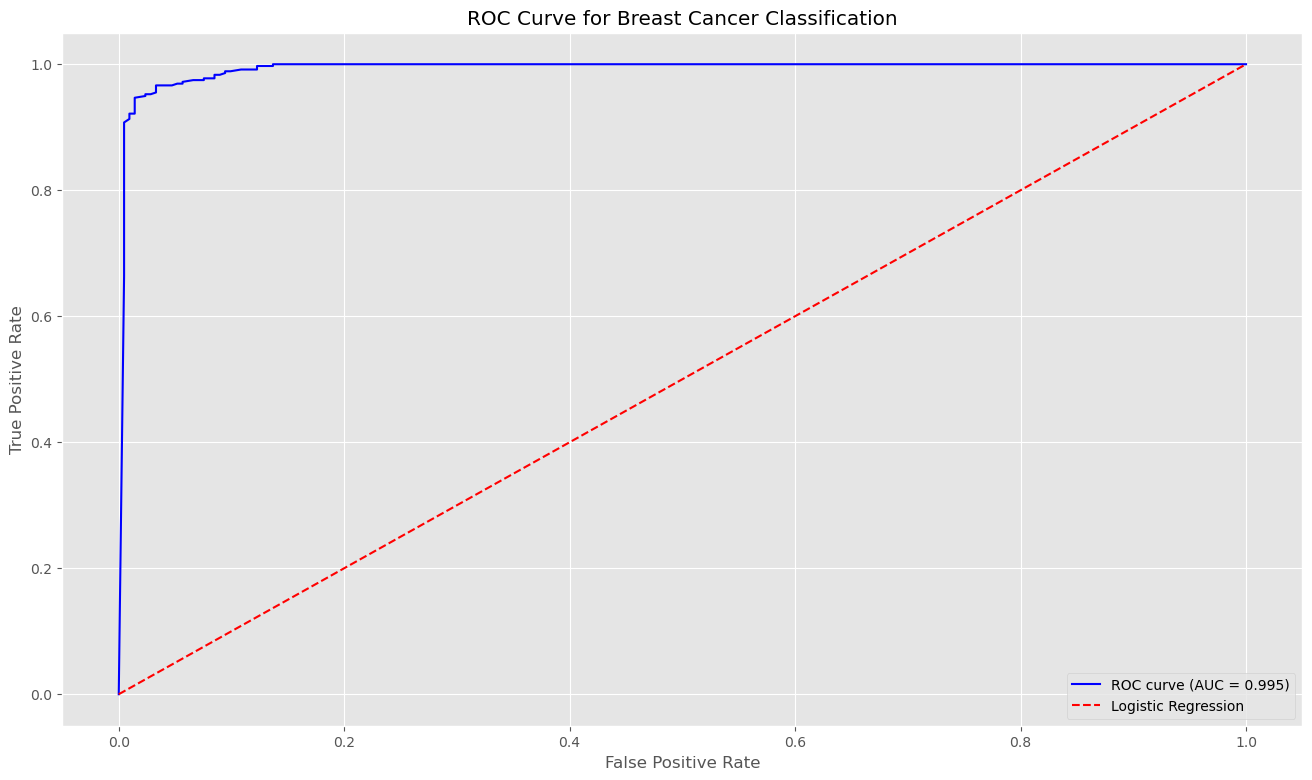

In [45]:
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (16,9)

# Get predicted probabilities
pred_proba = clf.predict_proba(X)[:, 1]

# Calculate FPR and TPR for different thresholds
FPR = []
TPR = []
# thresholds = np.arange(0.0, 1.01, 0.001)
thresholds = np.linspace(0, 1, 1000)

# get number of positive and negative examples in the dataset
P = sum(y)
N = len(y) - P

# iterate through all thresholds
for thresh in thresholds:
    FP = 0
    TP = 0
    thresh = round(thresh, 2)
    for i in range(len(pred_proba)):
        if pred_proba[i] >= thresh:
            if y[i] == 1:
                TP += 1
            else:
                FP += 1 
    FPR.append(FP/N)
    TPR.append(TP/P)

# Plot ROC curve
plt.plot(FPR, TPR, 'b-', label=f'ROC curve (AUC = {roc_auc_score(y, pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Breast Cancer Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Sort TPR and FPR arrays based on FPR for proper integration
sorted_indices = np.argsort(FPR)
sorted_FPR = np.array(FPR)[sorted_indices]
sorted_TPR = np.array(TPR)[sorted_indices]

# Custom integral calculation
def integral_roc(x, y):
    # Remove duplicates and sort
    unique_x_indices = np.unique(x, return_index=True)[1]
    x = x[unique_x_indices]
    y = y[unique_x_indices]
    
    # Calculate area using trapezoidal rule
    width = np.diff(x)
    height = (y[:-1] + y[1:]) / 2
    area = np.sum(width * height)
    return area

# Calculate ROC AUC using custom integral
roc_auc = integral_roc(sorted_FPR, sorted_TPR)
print(f"ROC AUC Score (using custom integral): {roc_auc:.3f}")

ROC AUC Score (using custom integral): 0.994
ROC AUC Score (using sklearn): 0.995


In [38]:
from scipy.integrate import trapz

# Sort TPR and FPR arrays based on FPR for proper integration
sorted_indices = np.argsort(FPR)
sorted_FPR = np.array(FPR)[sorted_indices]
sorted_TPR = np.array(TPR)[sorted_indices]

# Remove duplicates while preserving order
_, unique_indices = np.unique(sorted_FPR, return_index=True)
sorted_FPR = sorted_FPR[unique_indices]
sorted_TPR = sorted_TPR[unique_indices]

# Calculate ROC AUC using scipy.integrate.trapz
roc_auc = trapz(sorted_TPR, sorted_FPR)
print(f"ROC AUC Score (using scipy.integrate): {roc_auc:.3f}")

ROC AUC Score (using scipy.integrate): 0.994


C:\Users\Han\AppData\Local\Temp\ipykernel_27912\4079282274.py:14: DeprecationWarning: 'scipy.integrate.trapz' is deprecated in favour of 'scipy.integrate.trapezoid' and will be removed in SciPy 1.14.0
  roc_auc = trapz(sorted_TPR, sorted_FPR)


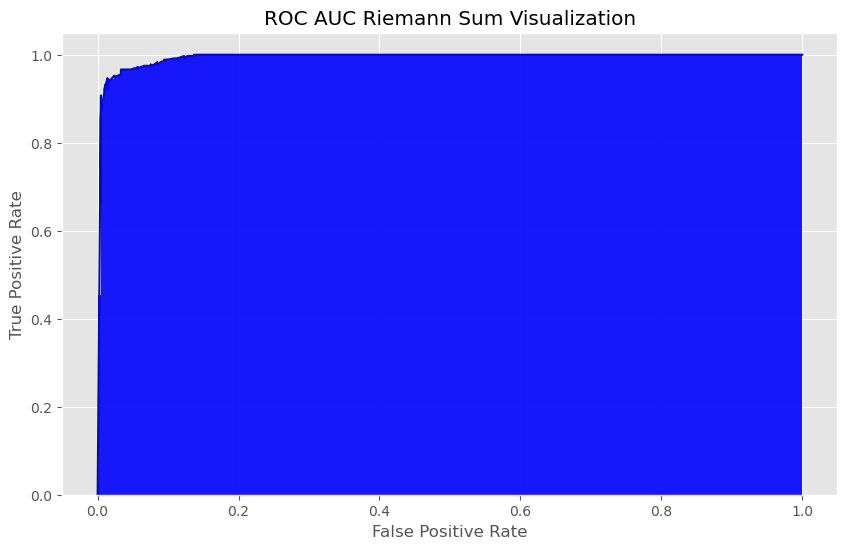

In [44]:
plt.figure(figsize=(10, 6))
width = np.diff(sorted_FPR)
height = (sorted_TPR[:-1] + sorted_TPR[1:]) / 2

plt.bar(sorted_FPR[:-1], height, width, alpha=0.9, align='edge', color='blue')
plt.plot(sorted_FPR, sorted_TPR, 'b-')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Riemann Sum Visualization')
plt.grid(True)
plt.show()
